In [1]:
  import numpy as np
  import matplotlib.pyplot as plt

In [2]:
import pandas
data = pandas.read_csv('/content/drive/MyDrive/Health Disease Risk assessment/input/diabetes.csv');

In [3]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
corr = data.corr()

In [7]:
corr['Outcome'].sort_values(ascending=False)

,Outcome
Outcome,1.000000
Glucose,0.466581
BMI,0.292695
Age,0.238356
Pregnancies,0.221898
DiabetesPedigreeFunction,0.173844
Insulin,0.130548
SkinThickness,0.074752
BloodPressure,0.065068


As we can see Glucose is a contributing factor for the outcome in here

Let's get started with EDA - Exploratory data analysis
1. Univariant analysis
2. bi-variant analysis

In [ ]:
# univariant analysis

In [8]:
# let's see the numerical features
numericalFeatures = data.select_dtypes(include=np.number)
categoricalFeatures = data.select_dtypes(include = object)

In [9]:
numericalFeatures.dtypes

,0
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


In [10]:
categoricalFeatures.dtypes

,0


In [11]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [12]:
data['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


we can see from above that, the it's an imbalanced dataset

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

In [16]:
data1 = data
data1['Outcome'] = data1['Outcome'].map({0:'Non-Diabetic',1:'Diabetic'})

<Axes: ylabel='count'>

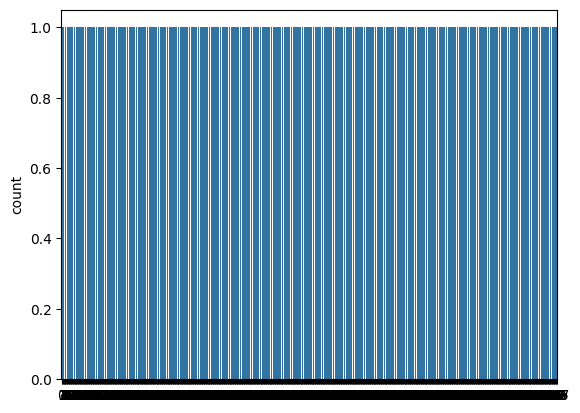

In [17]:
sns.countplot(data1['Outcome'])

(array([246., 178., 125.,  50.,  83.,  52.,  11.,  19.,   3.,   1.]),
 array([ 0. ,  1.7,  3.4,  5.1,  6.8,  8.5, 10.2, 11.9, 13.6, 15.3, 17. ]),
 <BarContainer object of 10 artists>)

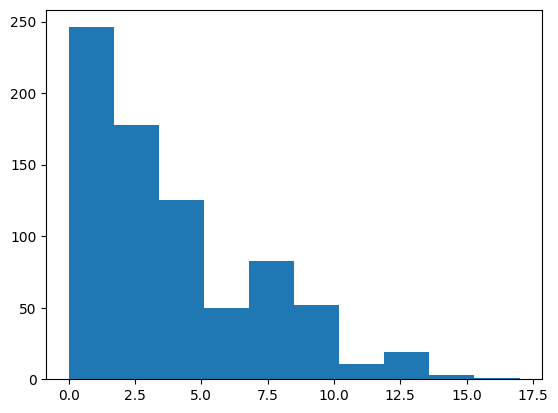

In [18]:
plt.hist(data['Pregnancies'])

In [19]:
Columns = list(data.columns)

In [20]:
Columns

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age',
 'Outcome']

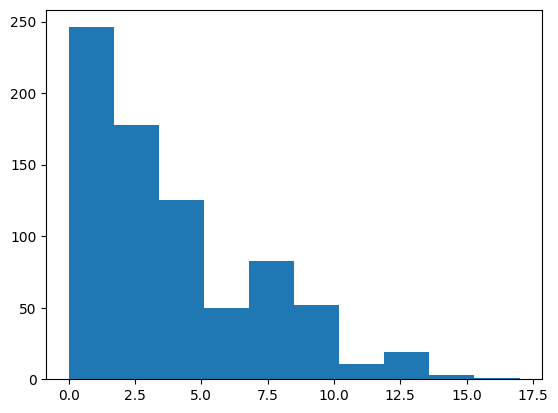

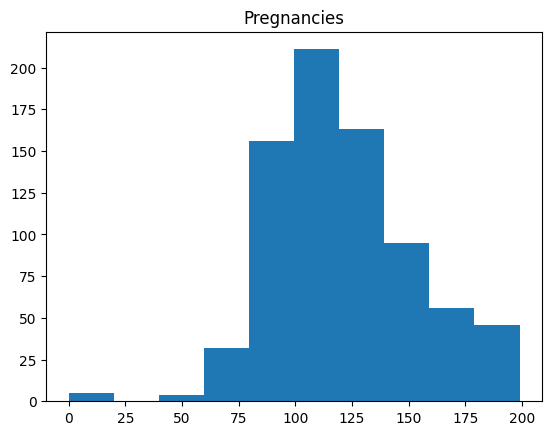

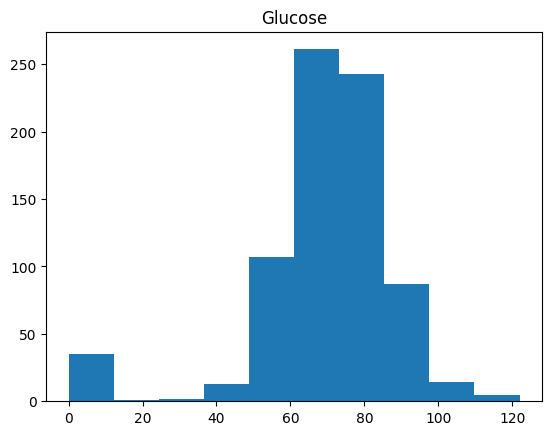

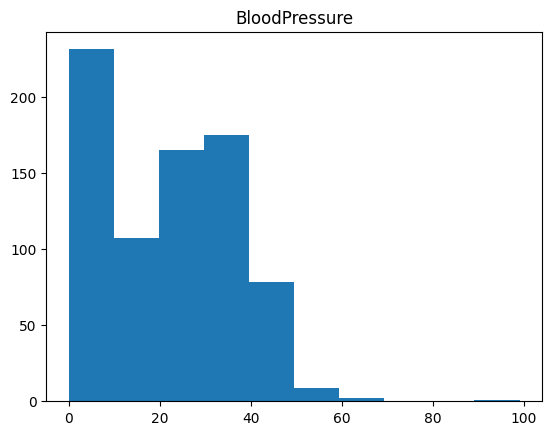

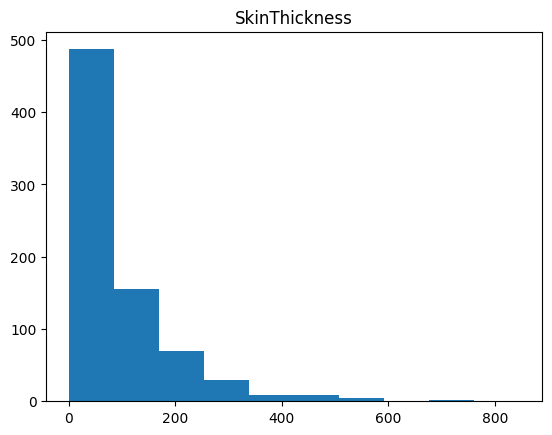

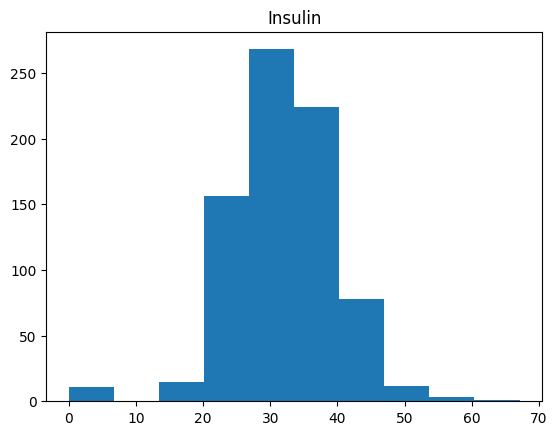

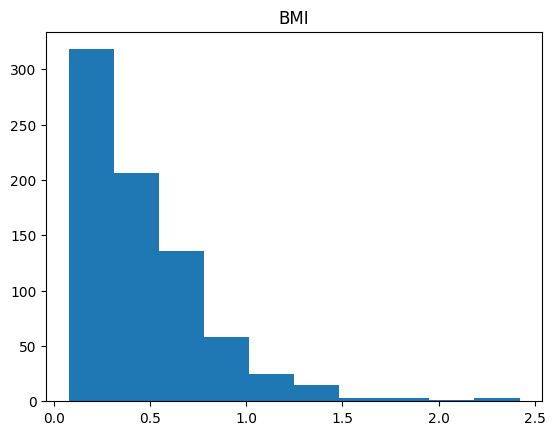

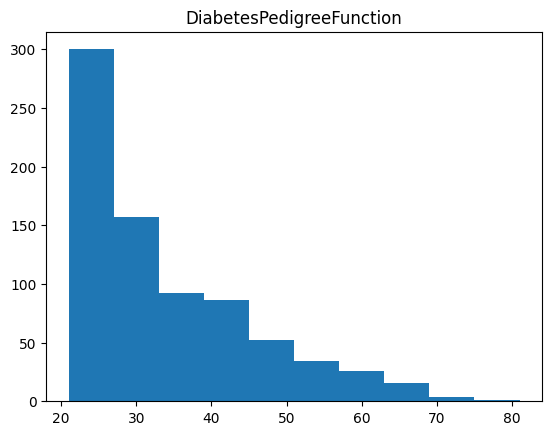

AttributeError: 'float' object has no attribute 'dtype'

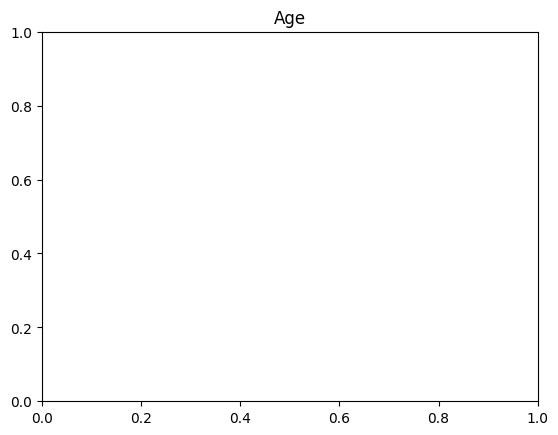

In [21]:
for i in Columns:
  plt.hist(data[i])
  plt.show()
  plt.title(i)

we have more non-diabetic instances than diabetic instances. the data is skewed, we need to divide the train and test data in such a way that train and test data will have equal portions of diabetic and non-diabetic patients. This is where cross valdiation comes in.

In [ ]:
# bivariant analysis

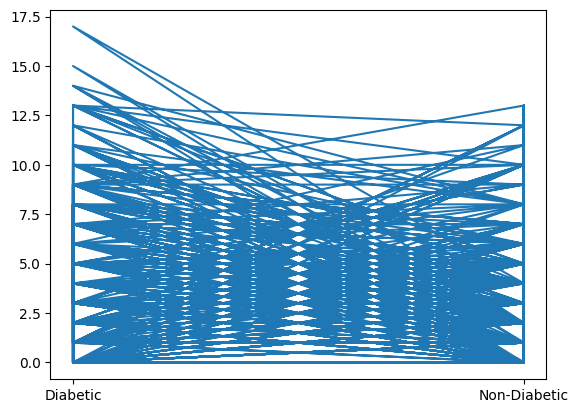

In [ ]:
plt.plot(data.Outcome,data.Pregnancies)

as we don't have any missing values, or outliers we are good with data processing

In [ ]:
# cross validation

In [ ]:
from sklearn import model_selection
data["kfold"] = -1

#randomize the rows of the data
data = data.sample(frac=1).reset_index(drop=True)

 # fetch labels
y = data.Outcome.values

# initiate the kfold class from model_selection module
kf = model_selection.StratifiedKFold(n_splits=5)

 # fill the new kfold column
for f, (t_, v_) in enumerate(kf.split(X=data, y=y)):
  data.loc[v_, 'kfold'] = f


In [ ]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,kfold
0,2,99,52,15,94,24.6,0.637,21,Non-Diabetic,0
1,1,109,38,18,120,23.1,0.407,26,Non-Diabetic,0
2,7,81,78,40,48,46.7,0.261,42,Non-Diabetic,0
3,10,162,84,0,0,27.7,0.182,54,Non-Diabetic,0
4,7,124,70,33,215,25.5,0.161,37,Non-Diabetic,0


In [ ]:
data[data['kfold'] == 0]['Outcome'].value_counts()

,count
Outcome,
Non-Diabetic,100
Diabetic,54


In [ ]:
Columns

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age',
 'Outcome']

In [ ]:
for i in Columns:
  print(i+": "+str(max(data[i])))

Pregnancies: 17
Glucose: 199
BloodPressure: 122
SkinThickness: 99
Insulin: 846
BMI: 67.1
DiabetesPedigreeFunction: 2.42
Age: 81
Outcome: Non-Diabetic


there are multiple outliers in the given readings. Let’s analyze them one by one:

**Pregnancies:** 17 – This is extremely high. The typical range is between 0 and 15, with most cases below 10.

**Glucose:** 199 – This is very high. Normal fasting glucose is below 100 mg/dL, and diabetes is diagnosed at 126 mg/dL or above.

**Blood Pressure:** 122 – This is within the normal to slightly elevated range, but not an extreme outlier.

**Skin Thickness:** 99 – This is extremely high. Normal values are around 10-50 mm.

**Insulin:** 846 – This is a strong outlier. Normal fasting insulin is usually below 300 pmol/L.

**BMI:** 67.1 – This is an extreme outlier. A BMI above 40 is considered severely obese.

**Diabetes Pedigree Function:** 2.42 – This is very high. Typical values range between 0 and 2, with most cases below 1.

**Age: **81 – While this is high, it is not necessarily an outlier.

In [ ]:
#handling outliers in the data

In [ ]:
data1 = data

In [ ]:
data1[data1['Insulin'] > 800]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,pregnancies
13,1,189,60,23,846,30.1,0.398,59,Diabetic,1


In [ ]:
data['pregnancies'] = np.where(data['Pregnancies'] > 10, 10, data['Pregnancies'])

In [ ]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,pregnancies
0,6,148,72,35,0,33.6,0.627,50,Diabetic,6
1,1,85,66,29,0,26.6,0.351,31,Non-Diabetic,1
2,8,183,64,0,0,23.3,0.672,32,Diabetic,8
3,1,89,66,23,94,28.1,0.167,21,Non-Diabetic,1
4,0,137,40,35,168,43.1,2.288,33,Diabetic,0


In [ ]:
data.pregnancies.value_counts()

,count
pregnancies,
1,135
0,111
2,103
3,75
4,68
10,58
5,57
6,50
7,45


In [ ]:
data.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0
pregnancies,0


In [ ]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,pregnancies
0,6,148,72,35,0,33.6,0.627,50,Diabetic,6
1,1,85,66,29,0,26.6,0.351,31,Non-Diabetic,1
2,8,183,64,0,0,23.3,0.672,32,Diabetic,8
3,1,89,66,23,94,28.1,0.167,21,Non-Diabetic,1
4,0,137,40,35,168,43.1,2.288,33,Diabetic,0


In [ ]:
import pandas as pd
from sklearn import model_selection
data["kfold"] = -1
# the next step is to randomize the rows of the data
data = data.sample(frac=1).reset_index(drop=True)
# fetch targets
y = data.Outcome.values
# initiate the kfold class from model_selection module
kf = model_selection.StratifiedKFold(n_splits=5)
# fill the new kfold column
for f, (t_, v_) in enumerate(kf.split(X=data, y=y)):
  data.loc[v_, 'kfold'] = f

In [ ]:
data[data['kfold'] == 0]['Outcome'].value_counts()

,count
Outcome,
Non-Diabetic,100
Diabetic,54


In [ ]:
data['kfold'].value_counts()

,count
kfold,
0,154
1,154
2,154
3,153
4,153


In [ ]:
# # model_dispatcher.py
import pandas as pd
import numpy as np
from sklearn.model_selection import RepeatedStratifiedKFold, train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, classification_report

models = {
    "logistic_regression": LogisticRegression( random_state=42),
    "decision_tree_gini": DecisionTreeClassifier(criterion="gini", random_state=42),
    "decision_tree_entropy": DecisionTreeClassifier(criterion="entropy", random_state=42),
    "random_forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "gradient_boosting": GradientBoostingClassifier(random_state=42),
    "ada_boost": AdaBoostClassifier(random_state=42),
    "extra_trees": ExtraTreesClassifier(class_weight='balanced', random_state=42),
    "naive_bayes": GaussianNB(),
    "svm": SVC(class_weight='balanced', random_state=42),
    "knn": KNeighborsClassifier()
}

In [ ]:
import joblib
import pandas as pd
from sklearn import metrics
from sklearn import tree
clf = models['decision_tree_entropy']
def run(fold):
 # read the training data with folds
 # training data is where kfold is not equal to provided fold
 # also, note that we reset the index
 df = data
 df_train = df[df.kfold != fold].reset_index(drop=True)
 # validation data is where kfold is equal to provided fold
 df_valid = df[df.kfold == fold].reset_index(drop=True)
 # drop the label column from dataframe and convert it to
 # a numpy array by using .values.
 # target is label column in the dataframe
 x_train = df_train.drop("Outcome", axis=1).values
 y_train = df_train.Outcome.values
 # similarly, for validation, we have
 x_valid = df_valid.drop("Outcome", axis=1).values
 y_valid = df_valid.Outcome.values
 # initialize simple decision tree classifier from sklearn

 # fit the model on training data
 clf.fit(x_train, y_train)
 # create predictions for validation samples
 preds = clf.predict(x_valid)

 # calculate & print accuracy
 accuracy = metrics.accuracy_score(y_valid, preds)
 print(f"Fold={fold}, Accuracy={accuracy}")
 # save the model
 #joblib.dump(clf, f"../models/dt_{fold}.bin")
if __name__ == "__main__":
 run(fold=0)
 run(fold=1)
 run(fold=2)
 run(fold=3)

Fold=0, Accuracy=0.7012987012987013
Fold=1, Accuracy=0.7077922077922078
Fold=2, Accuracy=0.7792207792207793
Fold=3, Accuracy=0.7516339869281046


In [ ]:
clf.save_model('model.pkl')

AttributeError: 'DecisionTreeClassifier' object has no attribute 'save_model'

In [ ]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,pregnancies,kfold
0,6,148,72,35,0,33.6,0.627,50,Diabetic,6,14
1,1,85,66,29,0,26.6,0.351,31,Non-Diabetic,1,10
2,8,183,64,0,0,23.3,0.672,32,Diabetic,8,12
3,1,89,66,23,94,28.1,0.167,21,Non-Diabetic,1,13
4,0,137,40,35,168,43.1,2.288,33,Diabetic,0,12


In [ ]:
data.kfold.value_counts()

,count
kfold,
10,154
11,154
12,154
14,153
13,153


In [ ]:
import pandas as pd
import numpy as np
import joblib
import sklearn
from sklearn.model_selection import RepeatedStratifiedKFold, train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

# Load dataset
#data = pd.read_csv('diabetes.csv')

# Create k-fold column if not already present
data['kfold'] = -1
kf = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
for fold, (_, valid_idx) in enumerate(kf.split(X=data, y=data['Outcome'])):
    data.loc[valid_idx, 'kfold'] = fold

# Define multiple models
models = {
    "logistic_regression": LogisticRegression(),
    "decision_tree_gini": DecisionTreeClassifier(criterion="gini"),
    "decision_tree_entropy": DecisionTreeClassifier(criterion="entropy"),
    "random_forest": RandomForestClassifier(),
    "gradient_boosting": GradientBoostingClassifier(),
    "ada_boost": AdaBoostClassifier(),
    "extra_trees": ExtraTreesClassifier(),
    "naive_bayes": GaussianNB(),
    "svm": SVC(),
    "knn": KNeighborsClassifier()
}

# Model training function
def run(fold, model_name):
    df_train = data[data.kfold != fold].reset_index(drop=True)
    df_valid = data[data.kfold == fold].reset_index(drop=True)

    x_train = df_train.drop("Outcome", axis=1).values
    y_train = df_train.Outcome.values
    x_valid = df_valid.drop("Outcome", axis=1).values
    y_valid = df_valid.Outcome.values

    clf = models[model_name]
    clf.fit(x_train, y_train)

    preds = clf.predict(x_valid)
    accuracy = metrics.accuracy_score(y_valid, preds)
    print(f"Model={model_name}, Fold={fold}, Accuracy={accuracy}")

    #joblib.dump(clf, f"models/{model_name}_{fold}.bin")

if __name__ == "__main__":
    for fold in range(11,14,1):  # 5 folds
        for model_name in models.keys():
            run(fold, model_name)


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Model=logistic_regression, Fold=11, Accuracy=0.7337662337662337
Model=decision_tree_gini, Fold=11, Accuracy=0.7272727272727273
Model=decision_tree_entropy, Fold=11, Accuracy=0.6363636363636364
Model=random_forest, Fold=11, Accuracy=0.7662337662337663
Model=gradient_boosting, Fold=11, Accuracy=0.7597402597402597
Model=ada_boost, Fold=11, Accuracy=0.7597402597402597
Model=extra_trees, Fold=11, Accuracy=0.7337662337662337
Model=naive_bayes, Fold=11, Accuracy=0.7402597402597403
Model=svm, Fold=11, Accuracy=0.7337662337662337
Model=knn, Fold=11, Accuracy=0.7142857142857143
Model=logistic_regression, Fold=12, Accuracy=0.7727272727272727
Model=decision_tree_gini, Fold=12, Accuracy=0.6753246753246753
Model=decision_tree_entropy, Fold=12, Accuracy=0.7337662337662337


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Model=random_forest, Fold=12, Accuracy=0.7922077922077922
Model=gradient_boosting, Fold=12, Accuracy=0.7597402597402597
Model=ada_boost, Fold=12, Accuracy=0.7597402597402597
Model=extra_trees, Fold=12, Accuracy=0.7727272727272727
Model=naive_bayes, Fold=12, Accuracy=0.7662337662337663
Model=svm, Fold=12, Accuracy=0.7532467532467533
Model=knn, Fold=12, Accuracy=0.7012987012987013
Model=logistic_regression, Fold=13, Accuracy=0.803921568627451
Model=decision_tree_gini, Fold=13, Accuracy=0.6993464052287581
Model=decision_tree_entropy, Fold=13, Accuracy=0.7254901960784313


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Model=random_forest, Fold=13, Accuracy=0.7973856209150327
Model=gradient_boosting, Fold=13, Accuracy=0.7908496732026143
Model=ada_boost, Fold=13, Accuracy=0.7647058823529411
Model=extra_trees, Fold=13, Accuracy=0.7777777777777778
Model=naive_bayes, Fold=13, Accuracy=0.803921568627451
Model=svm, Fold=13, Accuracy=0.803921568627451
Model=knn, Fold=13, Accuracy=0.7581699346405228


In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import RepeatedStratifiedKFold, train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
#data = pd.read_csv('diabetes.csv')

# Create k-fold column if not already present
data['kfold'] = -1
kf = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
for fold, (_, valid_idx) in enumerate(kf.split(X=data, y=data['Outcome'])):
    data.loc[valid_idx, 'kfold'] = fold

# Define multiple models
models = {
    "logistic_regression": LogisticRegression(),
    "decision_tree_gini": DecisionTreeClassifier(criterion="gini"),
    "decision_tree_entropy": DecisionTreeClassifier(criterion="entropy"),
    "random_forest": RandomForestClassifier(),
    "gradient_boosting": GradientBoostingClassifier(),
    "ada_boost": AdaBoostClassifier(),
    "extra_trees": ExtraTreesClassifier(),
    "svm": SVC(),
    "knn": KNeighborsClassifier()
}

# Define hyperparameter grids for tuning
param_distributions = {
    "logistic_regression": {"C": np.logspace(-4, 4, 10)},
    "decision_tree_gini": {"max_depth": [3, 5, 10, None], "criterion": ["gini"]},
    "decision_tree_entropy": {"max_depth": [3, 5, 10, None], "criterion": ["entropy"]},
    "random_forest": {"n_estimators": [50, 100, 200], "max_depth": [3, 5, 10, None]},
    "gradient_boosting": {"n_estimators": [50, 100, 200], "learning_rate": [0.01, 0.1, 0.2]},
    "ada_boost": {"n_estimators": [50, 100, 200], "learning_rate": [0.01, 0.1, 0.2]},
    "extra_trees": {"n_estimators": [50, 100, 200], "max_depth": [3, 5, 10, None]},
    "svm": {"C": [0.1, 1, 10], "kernel": ["linear", "rbf"]},
    "knn": {"n_neighbors": range(1, 15)}
}

# Model training function with hyperparameter tuning
def run(fold, model_name):
    df_train = data[data.kfold != fold].reset_index(drop=True)
    df_valid = data[data.kfold == fold].reset_index(drop=True)

    X_train = df_train.drop("Outcome", axis=1).values
    y_train = df_train.Outcome.values
    X_valid = df_valid.drop("Outcome", axis=1).values
    y_valid = df_valid.Outcome.values

    model = models[model_name]

    if model_name in param_distributions:
        search = RandomizedSearchCV(model, param_distributions=param_distributions[model_name],
                                    n_iter=10, cv=5, scoring='accuracy', random_state=42, n_jobs=-1)
        search.fit(X_train, y_train)
        best_model = search.best_estimator_
    else:
        best_model = model
        best_model.fit(X_train, y_train)

    preds = best_model.predict(X_valid)
    accuracy = accuracy_score(y_valid, preds)

    print(f"Model={model_name}, Fold={fold}, Accuracy={accuracy}, Best Params={search.best_params_ if model_name in param_distributions else 'N/A'}")

    # Save the best model
    #joblib.dump(best_model, f"models/{model_name}_{fold}.bin")

if __name__ == "__main__":
  for fold in range(11,14,1):  # 5 folds
      for model_name in models.keys():
          run(fold, model_name)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Model=logistic_regression, Fold=11, Accuracy=0.7337662337662337, Best Params={'C': np.float64(0.000774263682681127)}
Model=decision_tree_gini, Fold=11, Accuracy=0.7467532467532467, Best Params={'max_depth': 3, 'criterion': 'gini'}
Model=decision_tree_entropy, Fold=11, Accuracy=0.6558441558441559, Best Params={'max_depth': 3, 'criterion': 'entropy'}


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Model=random_forest, Fold=11, Accuracy=0.7532467532467533, Best Params={'n_estimators': 200, 'max_depth': 5}


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


...

Model=gradient_boosting, Fold=12, Accuracy=0.7792207792207793, Best Params={'n_estimators': 50, 'learning_rate': 0.1}


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Model=ada_boost, Fold=12, Accuracy=0.7857142857142857, Best Params={'n_estimators': 100, 'learning_rate': 0.1}
Model=extra_trees, Fold=12, Accuracy=0.7662337662337663, Best Params={'n_estimators': 200, 'max_depth': 10}


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


KeyboardInterrupt: 